# Experiment Validation

This notebook evaluates whether the A/B test satisfies the assumptions
required for valid causal inference.

In [33]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))

df = pd.read_csv("../data/processed/ab_data_cleaned.csv")

df.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


---
## Sample Ratio Mismatch (SRM)

We assess whether the observed allocation between control and treatment
groups is consistent with the expected 50/50 split.

A significant deviation may indicate issues in randomization, data
collection, or experiment execution, potentially invalidating causal inference.

In [34]:

from scipy.stats import chisquare

observed = df["group"].value_counts().reindex(["control", "treatment"]).fillna(0)
observed

group
control      146926
treatment    147552
Name: count, dtype: int64

The observed counts differ slightly between groups, which is expected due to
random variation. We now test whether this difference is statistically significant.

To formally evaluate this, we use a chi-square goodness-of-fit test.

The null hypothesis assumes that the observed group proportions follow the
expected allocation:

$H_0$: The observed frequencies match the expected 50/50 distribution

$H_1$: The observed frequencies deviate from the expected distribution

In [35]:
expected = pd.Series(
    [len(df) / 2, len(df) / 2],
    index=["control", "treatment"]
)

expected # 50/50 distribution

control      147239.0
treatment    147239.0
dtype: float64

In [36]:
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
SRM_result = [{"chi2_stat": chi2_stat, "p_value": p_value}]
pd.DataFrame(SRM_result)

,chi2_stat,p_value
0,1.330748,0.248672


The p-value is substantially higher than the typical significance
level (0.05), so we fail to reject the null hypothesis. This indicates 
that the observed allocation is consistent with the expected 50/50 split, and 
no evidence of sample ratio mismatch (SRM) is found.

This provides no evidence against the validity of the randomization process.

---
## Covariate Balance

We evaluate whether user characteristics are similarly distributed across
control and treatment groups.

In a properly randomized experiment, treatment assignment should be independent
of user attributes. Significant differences may indicate imbalance and threaten
the validity of causal inference.

We assess balance using:
- Chi-square tests for categorical variables
- Independent t-tests for continuous variables

### Categorical Variables

We test whether each categorical covariate is independent of the group
assignment using a chi-square test.

$H_0$: The covariate is independent of the group  
$H_1$: The covariate is associated with the group

In [37]:
from src import chi_square_group_test

categorical_cols = ["gender", "device_type", "location"]

cat_results = [chi_square_group_test(df, col) for col in categorical_cols]
pd.DataFrame(cat_results)

,variable,chi2_stat,p_value
0,gender,1.630628,0.442500
1,device_type,4.033750,0.133071
2,location,2.309945,0.889102


The p-values for all categorical variables are above the significance level,
indicating no statistically significant association between group assignment
and these features.

This provides no evidence of imbalance in categorical covariates.

### Continuous Variables

We compare the means between groups using Welch's t-test.

$H_0$: The means are equal across groups  
$H_1$: The means differ between groups

In [38]:
from src import t_test

continuous_cols = ["age", "session_duration"]

cont_results = [t_test(df, col) for col in continuous_cols]
pd.DataFrame(cont_results)

,variable,t_stat,p_value,control_mean,treatment_mean
0,age,-0.958901,0.337610,31.885704,31.918395
1,session_duration,0.423349,0.672041,5.003684,5.000594


The p-values for continuous variables are above the significance level,
indicating no statistically significant differences in means between groups.

This provides no evidence of differences in continuous covariates between groups.

### Temporal Consistency

We assess whether treatment assignment is independent of time.

Temporal imbalance may indicate issues such as:
- changes in traffic sources
- seasonality effects
- non-random assignment over time

We use a chi-square test of independence between group and date.

$H_0$: Group assignment is independent of time  
$H_1$: Group assignment is associated with time

In [39]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.date

start_date = df["date"].min()
end_date = df["date"].max()

print(f"The dataset spans from {start_date} to {end_date}.")

The dataset spans from 2023-08-30 to 2025-08-30.


The duration is unusually long for a typical A/B test, suggesting that the
dataset may represent aggregated or simulated data rather than a single
controlled experiment.

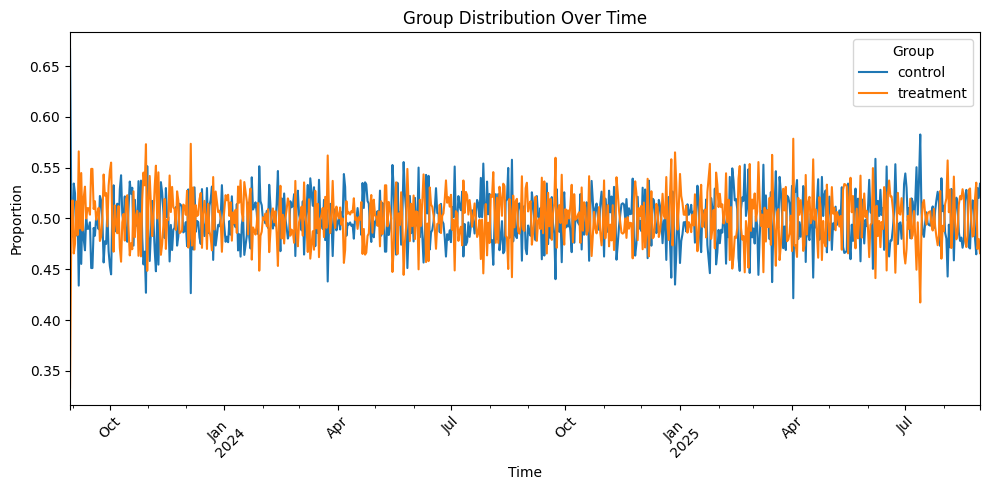

In [40]:
from src import plot_group_distribution_over_time

plot_group_distribution_over_time(df)

The plot shows the distribution of control and treatment groups over time.
We visually inspect that the proportions remain relatively stable over time.

Now, we perform the formal test on the distribution.

In [41]:
time_results = [chi_square_group_test(df, "date")]
pd.DataFrame(time_results)

,variable,chi2_stat,p_value
0,date,685.002038,0.887181


The p-value is above the significance threshold, indicating no evidence
against the null hypothesis.

This suggests that group assignment is not associated with time,
and no temporal imbalance is detected.

However, given the unusually long duration of the dataset, this result
should be interpreted with caution.

Note: Multiple hypothesis tests are performed for covariate balance.
Under proper randomization, some statistically significant results may occur
by chance alone. Therefore, results are interpreted collectively rather than
individually.

---
## Conclusion

No statistically significant differences were found between control and
treatment groups across both categorical and continuous variables. These results provide no evidence of imbalance in observed covariates.

Overall, the experiment appears sufficiently well-balanced to proceed
with causal analysis, with no detected violations of key assumptions.